In [1]:
import sys
import os

# Adds the parent directory (markerless-kinematics/) to the path
sys.path.append(os.path.abspath('..'))

# Now import your professional modules
from src.biomechanics import calculate_angle_3d, get_proportional_torque

Loading data from: ../data/processed/normal_gait_01.csv
Loading data from: ../data/processed/stiff_knee_01.csv


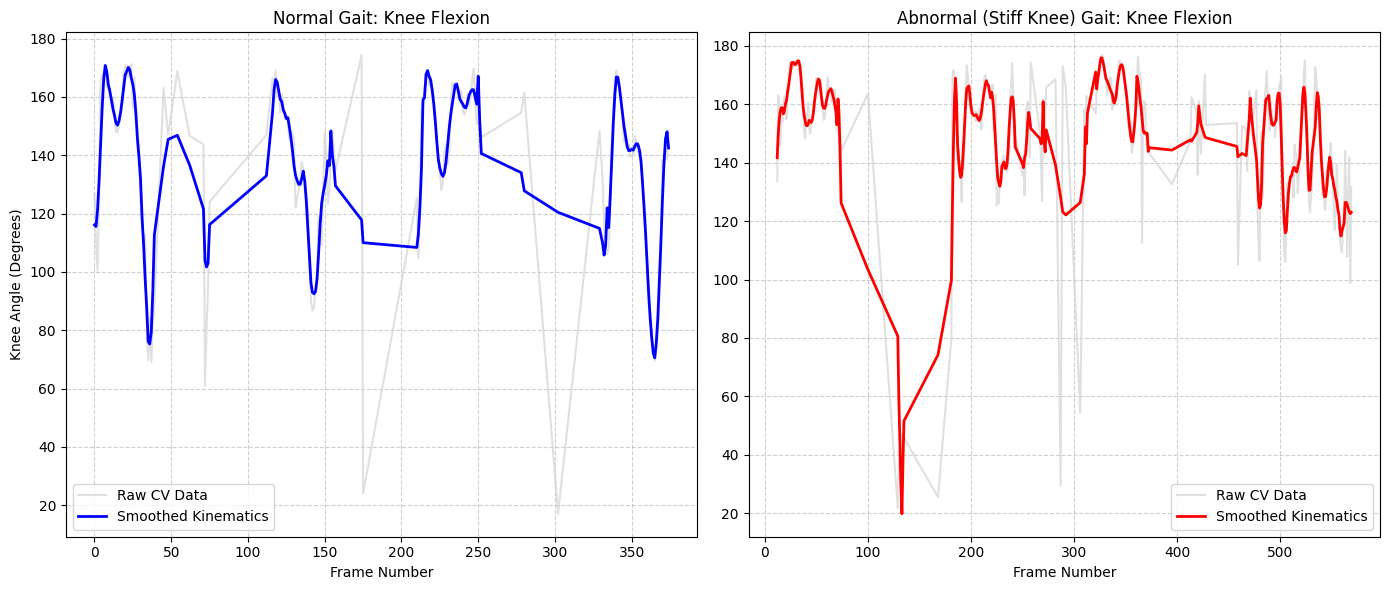

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def calculate_angle_3d(a, b, c):
    """Calculates the 3D angle between three points (a, b, c) with b as the vertex."""
    # Create vectors from the vertex (knee) to the endpoints (hip, ankle)
    ba = a - b
    bc = c - b
    
    # Calculate the dot product and the magnitudes of the vectors
    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    
    # Clip the value to prevent math domain errors due to floating point inaccuracies
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
    
    # Convert from radians to degrees
    return np.degrees(np.arccos(cosine_angle))

def process_kinematics(csv_path):
    print(f"Loading data from: {csv_path}")
    df = pd.read_csv(csv_path)
    
    angles = []
    # Iterate through each frame to calculate the angle
    for index, row in df.iterrows():
        hip = np.array([row['hip_x'], row['hip_y'], row['hip_z']])
        knee = np.array([row['knee_x'], row['knee_y'], row['knee_z']])
        ankle = np.array([row['ankle_x'], row['ankle_y'], row['ankle_z']])
        
        angle = calculate_angle_3d(hip, knee, ankle)
        angles.append(angle)
        
    df['knee_angle_raw'] = angles
    
    # Apply Savitzky-Golay filter to smooth the data
    # window_length=11 (frames), polyorder=3 (cubic polynomial)
    df['knee_angle_smoothed'] = savgol_filter(df['knee_angle_raw'], window_length=11, polyorder=3)
    
    return df

# Process both datasets
normal_df = process_kinematics('../data/processed/normal_gait_01.csv')
stiff_df = process_kinematics('../data/processed/stiff_knee_01.csv')

# Plot the results side-by-side
plt.figure(figsize=(14, 6))

# Plot 1: Normal Gait
plt.subplot(1, 2, 1)
plt.plot(normal_df['frame'], normal_df['knee_angle_raw'], color='lightgray', label='Raw CV Data', alpha=0.7)
plt.plot(normal_df['frame'], normal_df['knee_angle_smoothed'], color='blue', label='Smoothed Kinematics', linewidth=2)
plt.title('Normal Gait: Knee Flexion')
plt.xlabel('Frame Number')
plt.ylabel('Knee Angle (Degrees)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Abnormal (Stiff) Gait
plt.subplot(1, 2, 2)
plt.plot(stiff_df['frame'], stiff_df['knee_angle_raw'], color='lightgray', label='Raw CV Data', alpha=0.7)
plt.plot(stiff_df['frame'], stiff_df['knee_angle_smoothed'], color='red', label='Smoothed Kinematics', linewidth=2)
plt.title('Abnormal (Stiff Knee) Gait: Knee Flexion')
plt.xlabel('Frame Number')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Save the updated dataframes with the new angle features
normal_df.to_csv('../data/processed/normal_gait_with_angles.csv', index=False)
stiff_df.to_csv('../data/processed/stiff_knee_with_angles.csv', index=False)